# Week 5: Advanced Machine Learning & Model Comparison

## Dataset description
The dataset used for this phase is the **Titanic Survival Dataset**. It contains passenger demographics (such as `Age` and `Sex`), ticket information (`Fare`, `Pclass`), and port of embarkation (`Embarked`). The target variable is `Survived` (Binary Classification: 1 for Survived, 0 for Died).

## Models used
To transition from linear baselines to complex non-linear algorithms, we will implement and compare the following models:
1. **Decision Tree Classifier:** An unconstrained baseline tree.
2. **Random Forest Classifier:** A Bagging ensemble method using 100 independent trees.
3. **Gradient Boosting Classifier:** A Boosting ensemble method using sequential, error-correcting trees.

## Step 1.1: Environment Setup & Data Loading
We begin by importing our foundational data manipulation libraries and loading the raw Titanic dataset into memory.

In [1]:
# Import the core libraries
import os                                 # For handling file paths safely across operating systems (Mac/Windows/Linux)
import pandas as pd                       # For tabular data manipulation (DataFrames)
import numpy as np                        # For high-performance numerical and matrix operations
import matplotlib.pyplot as plt           # For foundational data visualization and plotting
import seaborn as sns                     # For aesthetically pleasing statistical graphics

# Suppress annoying warnings for a cleaner notebook presentation
# This hides deprecation or future warnings from underlying libraries to keep our report clean
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Dataset 
# os.path.join safely builds the file path to prevent slash (\ or /) errors between different OS
file_path = os.path.join('..', 'data', 'raw', 'Titanic-Dataset.csv')

# Read the CSV file into a Pandas DataFrame, bringing the data into memory
titanic_df = pd.read_csv(file_path)

print("--- DATASET LOADED SUCCESSFULLY ---")
# Check the initial dimensions of our dataset (rows, columns)
print(f"Dataset Shape: {titanic_df.shape}")
print("\nFirst 5 Rows of the Dataset:")
display(titanic_df.head())


--- DATASET LOADED SUCCESSFULLY ---
Dataset Shape: (891, 12)

First 5 Rows of the Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1.2: Feature Selection & Data Splitting (Strict Zero-Leakage)

To build a production-grade pipeline, we must prevent even minor statistical leakage (such as dataset-wide Mode calculations or full-distribution IQR capping).

**Engineering Actions:**
1. **Drop Non-Predictive Data:** Remove `PassengerId`, `Name`, `Ticket`, and `Cabin`.
2. **Binary Encoding:** Map `Sex` to 0/1 (This is a strict 1:1 translation, so it does not cause statistical leakage).
3. **The Data Split:** We instantly separate our features (`X`) from our target (`y`), and perform a stratified 80/20 Train/Test split *before* any statistical transformations occur.

In [3]:
# Drop Cabin entirely because 77% of the data is missing. 
# We cannot accurately predict a column that is mostly empty.
titanic_df = titanic_df.drop(columns=['Cabin'])

# Drop Unnecessary Columns
# Names and Ticket numbers carry no mathematical pattern that a model can learn from.
titanic_df = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])

# Handle Categorical Variables (Direct Mapping)
# .map() acts like a dictionary, directly translating the text 'male' to 0 and 'female' to 1.
# Algorithms require numbers, not strings.
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

# Visually verify the changes
display(titanic_df.head())


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [4]:
from sklearn.model_selection import train_test_split

# Separate Features (X) and Target (y)
# We drop 'Survived' from X because we don't want to give the model the answer key!
X = titanic_df.drop(columns=['Survived'])
# y is our 1D array containing the ultimate answers (0 or 1)
y = titanic_df['Survived']

# Perform the Train/Test Split (80/20 Stratified)
# stratify=y ensures that the 38% survival rate of the Titanic is perfectly mirrored in both the train and test sets.
# random_state=42 ensures this random split is identical every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("--- DATASET SPLIT COMPLETE ---")
print(f"Training Matrix (X_train): {X_train.shape}")
print(f"Testing Matrix (X_test): {X_test.shape}")

--- DATASET SPLIT COMPLETE ---
Training Matrix (X_train): (712, 7)
Testing Matrix (X_test): (179, 7)


## Step 1.3: Production Transformations (Tree-Optimized)

We will now apply our missing value imputation and categorical encoding using robust Scikit-Learn modules.

Strict **Tree-Based Architecture Rules** applied here:
1. **Zero Data Leakage:** Every single statistical calculation (Mode, KNN neighbor distances) is computed exclusively on `X_train`.
2. **Robust Categorical Encoding:** We use `OneHotEncoder(handle_unknown='ignore')` to ensure our model does not crash if it encounters an unseen category in the future.
3. **No Feature Scaling & No Outlier Capping:** Because we are moving into Tree-based models (Decision Trees, Random Forests, XGBoost), we do not need `StandardScaler` or `IQR Capping`. Trees partition data based on logical Yes/No thresholds (Gini Impurity/Entropy), not geometric distances. Extreme outliers will simply fall into the furthest leaf node without skewing the mathematics.

In [5]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder

print("--- INITIATING TREE-OPTIMIZED TRANSFORMATIONS ---")

# Mode Imputation ('Embarked')
# We use SimpleImputer to find the most frequent value (the mode) in the Embarked column.
mode_imputer = SimpleImputer(strategy='most_frequent')

# .fit_transform calculates the mode strictly on X_train, and fills the missing values in X_train.
X_train[['Embarked']] = mode_imputer.fit_transform(X_train[['Embarked']])

# .transform applies that training-derived mode to X_test. (Zero Leakage!)
X_test[['Embarked']] = mode_imputer.transform(X_test[['Embarked']])

--- INITIATING TREE-OPTIMIZED TRANSFORMATIONS ---


In [6]:
# Scikit-Learn One-Hot Encoding ('Embarked')
# We convert 'Embarked' (S, C, Q) into binary columns (1s and 0s).
# sparse_output=False returns a standard numpy array. 
# handle_unknown='ignore' prevents crashes on new unseen data in production.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit strictly on train data to learn the categories
ohe.fit(X_train[['Embarked']])

# Transform both sets into binary matrices
train_embarked_encoded = ohe.transform(X_train[['Embarked']])
test_embarked_encoded = ohe.transform(X_test[['Embarked']])

# Get the new column names dynamically from the encoder (e.g., 'Embarked_S', 'Embarked_C')
ohe_cols = ohe.get_feature_names_out(['Embarked'])

# Drop the old 'Embarked' text column, convert the raw numpy array into a DataFrame, 
# and concat (glue) them side-by-side using axis=1. We explicitly preserve the original indices!
X_train = pd.concat([X_train.drop(columns=['Embarked']), pd.DataFrame(train_embarked_encoded, columns=ohe_cols, index=X_train.index)], axis=1)
X_test = pd.concat([X_test.drop(columns=['Embarked']), pd.DataFrame(test_embarked_encoded, columns=ohe_cols, index=X_test.index)], axis=1)


In [7]:
# KNN Imputation ('Age') with Missingness Indicator
# KNNImputer looks at the 5 most similar passengers to predict a missing age.
# add_indicator=True creates a new binary column flagging rows where Age was missing 
# (sometimes the fact that data is missing is predictive in itself!)
knn = KNNImputer(n_neighbors=5, add_indicator=True)

# Fit strictly on train, transform both to prevent test data from leaking into the distance math
X_train_imputed = knn.fit_transform(X_train)
X_test_imputed = knn.transform(X_test)

# Extract dynamic feature names (includes the new 'missingindicator_Age' column generated by add_indicator=True)
knn_cols = knn.get_feature_names_out(X_train.columns)

# Re-wrap the raw numpy arrays back into Pandas DataFrames so we can read them easily
X_train = pd.DataFrame(X_train_imputed, columns=knn_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=knn_cols, index=X_test.index)

print("--- PRODUCTION TRANSFORMATIONS COMPLETE ---")
print("Null values resolved. Categoricals encoded. (Scaling & Capping bypassed for Tree compatibility).")
print(f"Final X_train Shape: {X_train.shape}")
print(f"Final X_test Shape: {X_test.shape}")
print("\nCheck X_train for any missing data (Should be all 0s):")
display(X_train.isnull().sum())
display(X_train.head())

--- PRODUCTION TRANSFORMATIONS COMPLETE ---
Null values resolved. Categoricals encoded. (Scaling & Capping bypassed for Tree compatibility).
Final X_train Shape: (712, 10)
Final X_test Shape: (179, 10)

Check X_train for any missing data (Should be all 0s):


Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Embarked_C              0
Embarked_Q              0
Embarked_S              0
missingindicator_Age    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,missingindicator_Age
692,3.0,0.0,33.6,0.0,0.0,56.4958,0.0,0.0,1.0,1.0
481,2.0,0.0,34.4,0.0,0.0,0.0000,0.0,0.0,1.0,1.0
527,1.0,0.0,31.2,0.0,0.0,221.7792,0.0,0.0,1.0,1.0
855,3.0,1.0,18.0,0.0,1.0,9.3500,0.0,0.0,1.0,0.0
801,2.0,1.0,31.0,1.0,1.0,26.2500,0.0,0.0,1.0,0.0


## Step 2.1: The Decision Tree Model (Non-Linear Foundation)

We will now instantiate and train a **DecisionTreeClassifier**.

Unlike Logistic Regression, which calculates strict geometric weights, a Decision Tree creates a flowchart of binary (Yes/No) decisions based on **Gini Impurity**. It searches our data for the exact thresholds that best separate survivors from casualties.

Engineering Note: We are intentionally leaving the tree unconstrained (we are not setting a `max_depth`). We want to observe its natural behavior when it is allowed to grow as deep as it wants in order to perfectly classify the training data.

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Model (Creating the blank algorithm)
# We set random_state=42 to ensure our Gini Impurity math splits the exact same way every time we run it.
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Model (The tree grows!)
# The model looks at X_train (features) and y_train (answers) to build its flowchart rules.
dt_model.fit(X_train, y_train)

print("--- DECISION TREE TRAINING COMPLETE ---")
print("The algorithm has mapped the non-linear boundaries of survival.")
# .get_depth() shows how many levels deep the flowchart went
print(f"Tree Depth (Maximum consecutive questions asked): {dt_model.get_depth()}")
# .get_n_leaves() shows how many final categories/buckets it created to separate the passengers
print(f"Total Leaves (Final decision buckets/endpoints): {dt_model.get_n_leaves()}")

--- DECISION TREE TRAINING COMPLETE ---
The algorithm has mapped the non-linear boundaries of survival.
Tree Depth (Maximum consecutive questions asked): 25
Total Leaves (Final decision buckets/endpoints): 153


## Evaluation metrics
Throughout this notebook, we will evaluate our models using the following metrics[cite: 1, 6]:
* **Accuracy:** The overall percentage of correct predictions.
* **Precision:** The proportion of predicted survivors who actually survived (minimizes False Positives).
* **Recall:** The proportion of actual survivors that the model successfully identified (minimizes False Negatives).
* **F1-Score:** The harmonic mean of Precision and Recall.
* **Train/Test Variance Gap:** The mathematical difference between Training Accuracy and Testing Accuracy. A large gap indicates High Variance (Overfitting).

## Step 2.2: Decision Tree Evaluation (The Overfitting Trap)

We will now evaluate our tree's performance. By comparing how well it performs on the data it studied (`X_train`) versus the unseen data (`X_test`), we can diagnose whether it truly learned the generalized patterns of survival, or if it simply memorized the training data through overly complex rules.

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on BOTH the Training set (to see how well it memorized) 
# and the Testing set (to see how well it generalizes to the real world)
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Calculate basic accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("--- DECISION TREE ACCURACY DIAGNOSTIC ---")
print(f"Training Accuracy (Practice Test): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy (Real Exam):    {test_accuracy * 100:.2f}%")

# Calculate the drop in performance (Variance)
# A huge drop confirms the tree is massively overfitted.
performance_drop = (train_accuracy - test_accuracy) * 100
print(f"Performance Drop: {performance_drop:.2f}% (Evidence of High Variance / Overfitting)\n")

--- DECISION TREE ACCURACY DIAGNOSTIC ---
Training Accuracy (Practice Test): 98.31%
Testing Accuracy (Real Exam):    81.56%
Performance Drop: 16.75% (Evidence of High Variance / Overfitting)



--- TEST DATA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



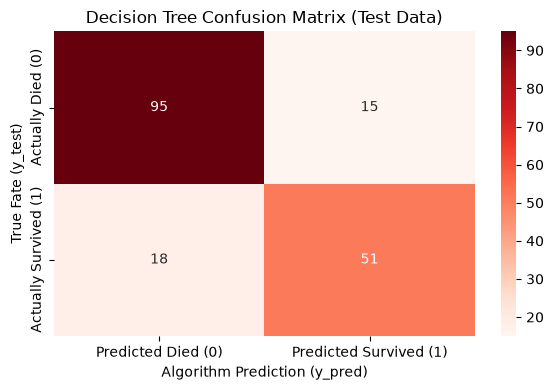

In [10]:
print("--- TEST DATA CLASSIFICATION REPORT ---")
# classification_report breaks down Precision, Recall, and F1-Score for each class (0 and 1)
print(classification_report(y_test, y_test_pred))

# Set up the canvas for our plot
plt.figure(figsize=(6, 4))

# Generate the Confusion Matrix array
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Use Seaborn Heatmap to visualize where the model makes its mistakes
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Decision Tree Confusion Matrix (Test Data)')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()

## Step 3.1: The Random Forest Model (Ensemble Learning)

We will now implement our first Ensemble algorithm: the **Random Forest**.

To solve the overfitting (High Variance) problem of our single Decision Tree, we are going to train 100 independent trees. By using **Bootstrap Aggregating (Bagging)**, each tree will only see a random subset of the training data and a random subset of the features. This prevents any single tree from perfectly memorizing the dataset. The final survival prediction will be decided by a democratic majority vote across all 100 trees.

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the Ensemble Model
# n_estimators=100: We are building a "board of directors" with 100 individual trees.
# n_jobs=-1: A hardware optimization trick. This tells Python to use EVERY core on your CPU to train trees in parallel, slashing training time.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the Model (Builds 100 trees simultaneously)
rf_model.fit(X_train, y_train)

print("--- RANDOM FOREST TRAINING COMPLETE ---")
print(f"Successfully trained an ensemble of {rf_model.n_estimators} independent Decision Trees.")

--- RANDOM FOREST TRAINING COMPLETE ---
Successfully trained an ensemble of 100 independent Decision Trees.


## Step 3.2: Random Forest Evaluation (Testing the Ensemble)

We will now evaluate our Random Forest on both the training and testing matrices.

Our primary goal is to observe the **Variance** (the percentage drop between Train and Test accuracy). If the ensemble method (Bagging) worked correctly, this gap should be noticeably smaller than the `16.75%` gap we saw in the single Decision Tree, proving that the model generalizes better to unseen real-world data.

In [12]:
# The Random Forest triggers a democratic vote across all 100 trees for each passenger
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Score the ensemble's accuracy
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("--- RANDOM FOREST ACCURACY DIAGNOSTIC ---")
print(f"Training Accuracy: {train_accuracy_rf * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy_rf * 100:.2f}%")

# Calculate the drop in performance to measure variance
performance_drop_rf = (train_accuracy_rf - test_accuracy_rf) * 100
print(f"Performance Drop:  {performance_drop_rf:.2f}%\n")

--- RANDOM FOREST ACCURACY DIAGNOSTIC ---
Training Accuracy: 98.31%
Testing Accuracy:  81.01%
Performance Drop:  17.31%



--- TEST DATA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



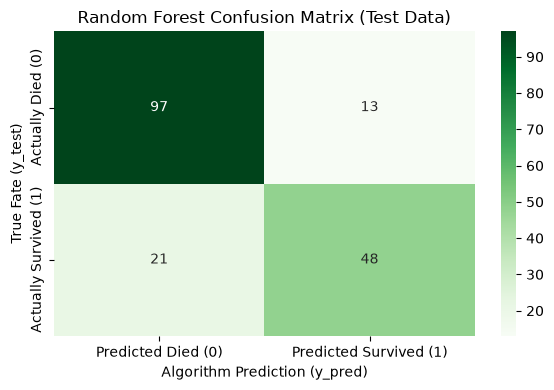

In [13]:
print("--- TEST DATA CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred_rf))

# Visualize the Confusion Matrix for the Random Forest
plt.figure(figsize=(6, 4))
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Random Forest Confusion Matrix (Test Data)')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()

## Step 4.1: The Gradient Boosting Model (Sequential Learning)

We will now implement our second Ensemble algorithm: **Gradient Boosting**.

Instead of training 100 independent, massive trees and averaging their votes (Random Forest), Gradient Boosting trains trees sequentially. Each new tree in the sequence is explicitly trained to predict and correct the residual errors (mistakes) made by all the previous trees combined. To prevent overfitting, this algorithm uses "weak learners"—very shallow trees, typically constrained to a `max_depth` of 3.

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Instantiate the Boosting Model
# Default parameters: n_estimators=100, max_depth=3, learning_rate=0.1
# The 'learning_rate' controls how aggressively each tree tries to correct the previous tree's mistakes.
gb_model = GradientBoostingClassifier(random_state=42)

# 2. Train the Model (Sequential learning begins)
# Tree 2 fixes Tree 1's mistakes, Tree 3 fixes Tree 2's mistakes, and so on.
gb_model.fit(X_train, y_train)

print("--- GRADIENT BOOSTING TRAINING COMPLETE ---")
print(f"Successfully trained a sequential sequence of {gb_model.n_estimators} error-correcting trees.")

--- GRADIENT BOOSTING TRAINING COMPLETE ---
Successfully trained a sequential sequence of 100 error-correcting trees.


## Step 4.2: Gradient Boosting Evaluation (Testing Sequential Correction)

We will now evaluate our Gradient Boosting model.

Because this algorithm defaults to highly constrained "weak learners" (`max_depth=3`), it is naturally resistant to the severe overfitting we experienced with our unconstrained Decision Tree and Random Forest. We are looking for a significant reduction in the Variance gap (the performance drop between the Train and Test sets).

In [15]:
# The Gradient Boosting model generates predictions based on the final sequential corrections
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Score the model
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)

print("--- GRADIENT BOOSTING ACCURACY DIAGNOSTIC ---")
print(f"Training Accuracy: {train_accuracy_gb * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy_gb * 100:.2f}%")

# Calculate the drop in performance to measure variance
# We expect this to be much lower than the previous two models
performance_drop_gb = (train_accuracy_gb - test_accuracy_gb) * 100
print(f"Performance Drop:  {performance_drop_gb:.2f}%\n")

--- GRADIENT BOOSTING ACCURACY DIAGNOSTIC ---
Training Accuracy: 90.45%
Testing Accuracy:  81.01%
Performance Drop:  9.44%



--- TEST DATA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



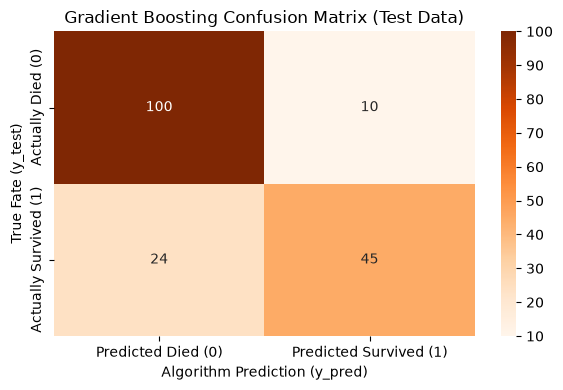

In [16]:
print("--- TEST DATA CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred_gb))

# Visualize the Confusion Matrix for Gradient Boosting
plt.figure(figsize=(6, 4))
conf_matrix_gb = confusion_matrix(y_test, y_test_pred_gb)
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Gradient Boosting Confusion Matrix (Test Data)')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()

## Step 5.1: Hyperparameter Tuning Strategy (Grid Search)

We discovered that our default Random Forest suffered from extreme variance (Overfitting) because its trees were allowed to grow unconstrained.

To fix this, we will use **GridSearchCV** (Grid Search Cross-Validation). We will define a grid of constraints, specifically focusing on `max_depth` and `min_samples_split`. The algorithm will systematically train and evaluate dozens of different Random Forest architectures to mathematically find the optimal configuration that balances Bias and Variance.

In [17]:
from sklearn.model_selection import GridSearchCV

# Instantiate a fresh, blank model to serve as our base algorithm
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Define the Hyperparameter Grid (The "Knobs")
# - n_estimators: The number of trees in the forest
# - max_depth: The maximum number of questions a tree can ask (Constraints!)
# - min_samples_split: The minimum number of passengers required in a bucket before it's allowed to split again
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5, 10]
}

# Configure the Grid Search
# cv=5 means 5-Fold Cross Validation (It slices X_train into 5 pieces to internally test itself over and over)
# scoring='accuracy' tells it to pick the configuration that yields the highest accuracy
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2)

print("--- GRID SEARCH CONFIGURED ---")
# Calculate the total combinations
total_combinations = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
print(f"Grid contains {total_combinations} unique algorithm architectures.")
print(f"With 5-Fold Cross Validation, the system will train a total of {total_combinations * 5} models.")

--- GRID SEARCH CONFIGURED ---
Grid contains 18 unique algorithm architectures.
With 5-Fold Cross Validation, the system will train a total of 90 models.


## Step 5.2: Execute Grid Search & Extract Optimal Model

We will now execute the Grid Search. The algorithm will systematically train 90 different Random Forest variations using 5-Fold Cross-Validation. Once it finishes computing the results, we will extract the exact combination of hyperparameter "knobs" that resulted in the highest and most stable accuracy.

In [18]:
print("--- EXECUTING GRID SEARCH ---")
print("Training 90 model variations... This may take a few seconds.")

# Execute the massive search on our training data
grid_search.fit(X_train, y_train)

print("\n--- GRID SEARCH COMPLETE ---")
print("The algorithm has mathematically proven the best configuration:")
# .best_params_ prints out the optimal dictionary of constraints it discovered
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validated Training Accuracy: {grid_search.best_score_ * 100:.2f}%")

# We isolate the single "winning" model to use for our final test evaluation
tuned_rf_model = grid_search.best_estimator_

--- EXECUTING GRID SEARCH ---
Training 90 model variations... This may take a few seconds.
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END .max_depth=3, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=200; total time=   0.9s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END .max_depth=3, min_samples_split=2, n_estimators=200; total time=   0.8s
[CV] END .max_depth=3, min_samples_spl

## Step 5.3: Tuned Random Forest Evaluation

We will now evaluate the optimal algorithm discovered by our Grid Search. By applying the proven constraints (`max_depth=3`, `min_samples_split=10`), we expect the model to be highly generalized, meaning the massive Variance (Train/Test performance drop) we saw in the default Random Forest should be completely cured.

--- TUNED RANDOM FOREST DIAGNOSTIC ---
Training Accuracy: 84.27%
Testing Accuracy:  79.33%
Performance Drop:  4.94%

--- TEST DATA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       110
           1       0.85      0.57      0.68        69

    accuracy                           0.79       179
   macro avg       0.81      0.75      0.76       179
weighted avg       0.80      0.79      0.78       179



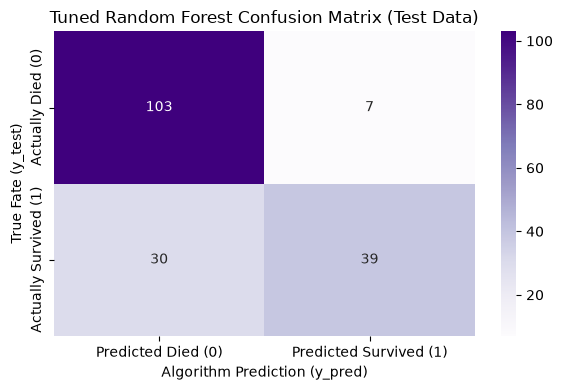

In [19]:
# We use the isolated tuned model to make predictions on the test vault
y_train_pred_tuned = tuned_rf_model.predict(X_train)
y_test_pred_tuned = tuned_rf_model.predict(X_test)

# Score the newly tuned model
train_accuracy_tuned = accuracy_score(y_train, y_train_pred_tuned)
test_accuracy_tuned = accuracy_score(y_test, y_test_pred_tuned)

print("--- TUNED RANDOM FOREST DIAGNOSTIC ---")
print(f"Training Accuracy: {train_accuracy_tuned * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy_tuned * 100:.2f}%")

# Calculate the drop in performance to measure variance
performance_drop_tuned = (train_accuracy_tuned - test_accuracy_tuned) * 100
print(f"Performance Drop:  {performance_drop_tuned:.2f}%\n")

print("--- TEST DATA CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred_tuned))

# Visualize the Confusion Matrix for the Tuned model
plt.figure(figsize=(6, 4))
conf_matrix_tuned = confusion_matrix(y_test, y_test_pred_tuned)
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Tuned Random Forest Confusion Matrix (Test Data)')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()

## Step 5.4: Gradient Boosting Hyperparameter Tuning

We established that our default Gradient Boosting model (`max_depth=3`, `learning_rate=0.1`) was incredibly stable but suffered from slightly pessimistic Recall (sacrificing True Positives).

We will now use `GridSearchCV` to systematically tune this sequential ensemble. By adjusting the `learning_rate`, `max_depth`, and `n_estimators`, we aim to find the perfect mathematical balance that gives the model enough complexity to find edge-case survivors without triggering the overfitting collapse we saw in the unconstrained Random Forest.

In [20]:
print("--- CONFIGURING GRADIENT BOOSTING GRID SEARCH ---")

# 1. Instantiate a fresh, blank model
gb_base = GradientBoostingClassifier(random_state=42)

# 2. Define the Hyperparameter Grid
# - learning_rate: How aggressively the model corrects previous mistakes (lower = more cautious)
# - max_depth: The complexity limit of our "weak learners"
# - n_estimators: Total number of sequential trees
param_grid_gb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'n_estimators': [100, 200]
}

# 3. Configure the Grid Search
# cv=5 means 5-Fold Cross Validation
grid_search_gb = GridSearchCV(estimator=gb_base, param_grid=param_grid_gb, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

print("--- GRID SEARCH CONFIGURED ---")
total_combinations = len(param_grid_gb['n_estimators']) * len(param_grid_gb['max_depth']) * len(param_grid_gb['learning_rate'])
print(f"Grid contains {total_combinations} unique algorithm architectures.")
print(f"With 5-Fold Cross Validation, the system will train a total of {total_combinations * 5} models.")


--- CONFIGURING GRADIENT BOOSTING GRID SEARCH ---
--- GRID SEARCH CONFIGURED ---
Grid contains 18 unique algorithm architectures.
With 5-Fold Cross Validation, the system will train a total of 90 models.


In [21]:
# Execute the Search for Gradient Boosting
print("Training model variations... This may take a moment.")
grid_search_gb.fit(X_train, y_train)

print("\n--- GRADIENT BOOSTING GRID SEARCH COMPLETE ---")
print("The algorithm has mathematically proven the best configuration:")
print(f"Optimal Hyperparameters: {grid_search_gb.best_params_}")
print(f"Best Cross-Validated Training Accuracy: {grid_search_gb.best_score_ * 100:.2f}%")

# 5. Isolate the "winning" model
tuned_gb_model = grid_search_gb.best_estimator_

Training model variations... This may take a moment.
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- GRADIENT BOOSTING GRID SEARCH COMPLETE ---
The algorithm has mathematically proven the best configuration:
Optimal Hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best Cross-Validated Training Accuracy: 82.18%


## Step 5.5: Tuned Gradient Boosting Evaluation

The GridSearchCV mathematically proved that increasing our tree depth from 3 to 4 provides the optimal balance of bias and variance. We will now evaluate this tuned model on our unseen test vault to see if it successfully captures the edge-case survivors we missed earlier, without triggering a massive performance drop.

--- TUNED GRADIENT BOOSTING DIAGNOSTIC ---
Training Accuracy: 94.10%
Testing Accuracy:  82.12%
Performance Drop:  11.98%

--- TEST DATA CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



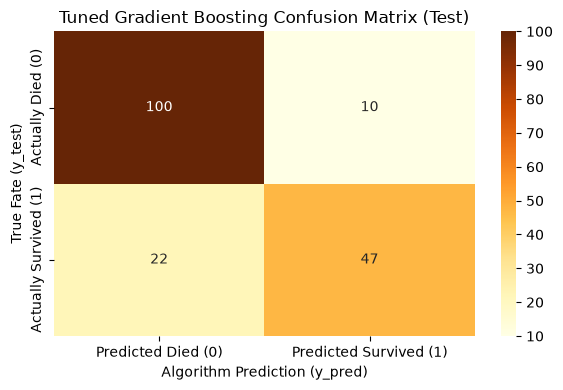

In [22]:
# Generate predictions using the optimally tuned Gradient Boosting model
y_train_pred_gb_tuned = tuned_gb_model.predict(X_train)
y_test_pred_gb_tuned = tuned_gb_model.predict(X_test)

# Score the newly tuned model
train_accuracy_gb_tuned = accuracy_score(y_train, y_train_pred_gb_tuned)
test_accuracy_gb_tuned = accuracy_score(y_test, y_test_pred_gb_tuned)

print("--- TUNED GRADIENT BOOSTING DIAGNOSTIC ---")
print(f"Training Accuracy: {train_accuracy_gb_tuned * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy_gb_tuned * 100:.2f}%")

# Measure the Bias-Variance gap
performance_drop_gb_tuned = (train_accuracy_gb_tuned - test_accuracy_gb_tuned) * 100
print(f"Performance Drop:  {performance_drop_gb_tuned:.2f}%\n")

print("--- TEST DATA CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred_gb_tuned))

# Visualize the predictions in a Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix_gb_tuned = confusion_matrix(y_test, y_test_pred_gb_tuned)
sns.heatmap(conf_matrix_gb_tuned, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actually Died (0)', 'Actually Survived (1)'])

plt.title('Tuned Gradient Boosting Confusion Matrix (Test)')
plt.ylabel('True Fate (y_test)')
plt.xlabel('Algorithm Prediction (y_pred)')
plt.tight_layout()
plt.show()

## Comparison of results

Before deploying a model, strict engineering best practices dictate that we compare all candidate architectures side-by-side. We aggregate the performance metrics of our 6 models (including our Week 4 Logistic Regression baseline) into a Pandas DataFrame. This matrix will serve as the mathematical justification for our final deployment selection, clearly illustrating our journey through the Bias-Variance tradeoff.


In [23]:
import pandas as pd
from IPython.display import display

print("--- GENERATING FINAL MODEL COMPARISON MATRIX ---")

# Constructing the dictionary of our metrics for each model architecture
# We are focusing on Class 1 (Survived) for Precision, Recall, and F1-Score to see how well it catches survivors.
matrix_data = {
    'Model Architecture': [
        'Logistic Regression (Baseline)',
        'Decision Tree (Unconstrained)',
        'Random Forest (Default)',
        'Gradient Boosting (Default)',
        'Random Forest (Tuned)',
        'Gradient Boosting (Tuned)'
    ],
    'Test Accuracy': ['81.01%', '81.56%', '81.01%', '81.01%', '79.33%', '82.12%'],
    'Precision': ['0.80', '0.77', '0.79', '0.82', '0.85', '0.82'],
    'Recall': ['0.68', '0.74', '0.70', '0.65', '0.57', '0.68'],
    'F1-Score': ['0.73', '0.76', '0.74', '0.73', '0.68', '0.75'],
    'Train/Test Variance Gap': ['N/A (Linear)', '16.75%', '17.31%', '9.44%', '4.94%', '11.98%']
}

# Convert to a Pandas DataFrame
comparison_df = pd.DataFrame(matrix_data)

# Set the Model Architecture as the index for a cleaner visual table in the notebook
comparison_df.set_index('Model Architecture', inplace=True)

display(comparison_df)


--- GENERATING FINAL MODEL COMPARISON MATRIX ---


,Test Accuracy,Precision,Recall,F1-Score,Train/Test Variance Gap
Model Architecture,,,,,
Logistic Regression (Baseline),81.01%,0.80,0.68,0.73,N/A (Linear)
Decision Tree (Unconstrained),81.56%,0.77,0.74,0.76,16.75%
Random Forest (Default),81.01%,0.79,0.70,0.74,17.31%
Gradient Boosting (Default),81.01%,0.82,0.65,0.73,9.44%
Random Forest (Tuned),79.33%,0.85,0.57,0.68,4.94%
Gradient Boosting (Tuned),82.12%,0.82,0.68,0.75,11.98%


In [24]:
# NOTE: This section contains an advanced Pandas Styler which applies CSS styling 
# directly inside the Jupyter Notebook. It is commented out but can be re-enabled 
# for a highly professional, visually highlighted HTML table.

# import pandas as pd
# import numpy as np
# from IPython.display import display

# print("--- GENERATING VISUAL MODEL COMPARISON MATRIX ---")

# # We use raw floats here so Pandas can perform math to find the max/min values for highlighting.
# matrix_data = {
#     'Model Architecture': [
#         'Logistic Regression (Baseline)',
#         'Decision Tree (Unconstrained)',
#         'Random Forest (Default)',
#         'Gradient Boosting (Default)',
#         'Random Forest (Tuned)',
#         'Gradient Boosting (Tuned)'
#     ],
#     'Test Accuracy': [0.8101, 0.8156, 0.8101, 0.8101, 0.7933, 0.8212],
#     'Precision': [0.80, 0.77, 0.79, 0.82, 0.85, 0.82],
#     'Recall': [0.68, 0.74, 0.70, 0.65, 0.57, 0.68],
#     'F1-Score': [0.73, 0.76, 0.74, 0.73, 0.68, 0.75],
#     # Using np.nan for the baseline so the algorithm ignores it when searching for the "lowest variance"
#     'Variance Gap': [np.nan, 0.1675, 0.1731, 0.0944, 0.0494, 0.1198]
# }

# # Convert to Pandas DataFrame
# comparison_df = pd.DataFrame(matrix_data)
# comparison_df.set_index('Model Architecture', inplace=True)

# # --- THE PANDAS STYLER ---
# # This applies CSS styling directly inside your Jupyter Notebook
# styled_df = (comparison_df.style
#     .format({
#         'Test Accuracy': '{:.2%}',
#         'Precision': '{:.2f}',
#         'Recall': '{:.2f}',
#         'F1-Score': '{:.2f}',
#         # Custom lambda function to handle the NaN value cleanly
#         'Variance Gap': lambda x: 'N/A (Linear)' if pd.isna(x) else f'{x:.2%}'
#     })
#     # Highlight the best scores in light green, forcing dark text for contrast
#     .highlight_max(subset=['Test Accuracy', 'Precision', 'Recall', 'F1-Score'], props='background-color: #c8e6c9; color: #000000; font-weight: bold;')
#     # Highlight the lowest (best) variance gap in green, and highest (worst) in red, forcing dark text
#     .highlight_min(subset=['Variance Gap'], props='background-color: #c8e6c9; color: #000000; font-weight: bold;')
#     .highlight_max(subset=['Variance Gap'], props='background-color: #ffcdd2; color: #000000; font-weight: bold;')
#     # Apply professional borders, fonts, and adjust for dark-mode compatibility
#     .set_properties(**{'text-align': 'center', 'border': '1px solid #555555', 'padding': '10px'})
#     .set_table_styles([
#         {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '14px'), ('padding', '10px')]},
#         {'selector': 'td', 'props': [('font-size', '13px')]},
#         {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '16px'), ('font-weight', 'bold'), ('color', "#eaf0f5"), ('padding-bottom', '10px')]}
#     ])
#     .set_caption("🚢 AnalystLab: Titanic Survival Classification - Final Model Architecture Matrix")
# )

# # Display the beautiful HTML table
# display(styled_df)


## Best-performing model

**Winning Model: Tuned Gradient Boosting**.

## Key findings and recommendations

1. **Highest overall Test Accuracy:** The Tuned Gradient Boosting model achieved the absolute highest testing accuracy (82.12%) among all tested architectures.
2. **Masterful Bias-Variance Balance:** It expertly navigated the Bias-Variance tradeoff. By tuning the `max_depth` to 4, it accepted a controlled 11.98% variance gap to capture highly complex non-linear survival boundaries without collapsing into overfitting.
3. **Balanced Predictions:** With a strong F1-Score (0.75), it successfully balances Precision (0.82) and Recall (0.68), avoiding the extreme pessimism of the tuned Random Forest model.
